# 05 — Training, Evaluation, and Comparison (4-experiment ladder)

Runs the full experimental ladder from
[docs/ml-design-report.md §7](../docs/ml-design-report.md#7-experimental-ladder-planned-runs):

| # | Encoder | Objective |
|---|---|---|
| 1 | GRU | classification-only |
| 2 | GRU | classification + HRF regression |
| 3 | Transformer | classification-only |
| 4 | Transformer | classification + HRF regression |

Fixed for this first pass (per plan): 5 training epochs, AdamW + cosine LR
annealing, `lambda_hrf = 0.1`, subject-level split (train =
`100307, 100408, 101006`, val = `101107`, test = `101309`). Model checkpoints
are saved locally under `models/` (gitignored); the consolidated metrics are
saved to `results/motor_v1_results.json` and committed, since that's the
artifact worth keeping in version control.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders
from neurolens.engine import TrainConfig, get_device, train_experiment
from neurolens.model_builder import GRUDecoder, TransformerDecoder, count_parameters

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

SEED = 42
NUM_EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4
LAMBDA_HRF = 0.1
BATCH_SIZE = 64

print("device:", get_device())

train_loader, val_loader, test_loader, info = make_dataloaders(PROCESSED_ROOT, batch_size=BATCH_SIZE)
print({k: v for k, v in info.items() if k != "class_weights"})


device: mps
{'num_classes': 6, 'num_conditions': 5, 'n_train_windows': 3556, 'n_val_windows': 762, 'n_test_windows': 762, 'class_to_condition': {'0': 'baseline', '1': 'left_hand', '2': 'right_hand', '3': 'left_foot', '4': 'right_foot', '5': 'tongue'}, 'condition_names': ['left_hand', 'right_hand', 'left_foot', 'right_foot', 'tongue']}


## Run all four experiments

In [2]:
def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)


EXPERIMENTS = [
    {
        "name": "exp1_gru_cls_only",
        "encoder": "GRU",
        "objective": "classification-only",
        "model_fn": lambda: GRUDecoder(
            num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False
        ),
    },
    {
        "name": "exp2_gru_multitask",
        "encoder": "GRU",
        "objective": "classification + HRF",
        "model_fn": lambda: GRUDecoder(
            num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True
        ),
    },
    {
        "name": "exp3_transformer_cls_only",
        "encoder": "Transformer",
        "objective": "classification-only",
        "model_fn": lambda: TransformerDecoder(
            num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False
        ),
    },
    {
        "name": "exp4_transformer_multitask",
        "encoder": "Transformer",
        "objective": "classification + HRF",
        "model_fn": lambda: TransformerDecoder(
            num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True
        ),
    },
]

all_results = {}
for exp in EXPERIMENTS:
    set_seed(SEED)
    model = exp["model_fn"]()
    n_params = count_parameters(model)
    config = TrainConfig(
        experiment_name=exp["name"],
        num_epochs=NUM_EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        lambda_hrf=LAMBDA_HRF,
        checkpoint_dir=MODELS_DIR / exp["name"],
    )
    result = train_experiment(model, train_loader, val_loader, test_loader, info["num_classes"], info["class_weights"], config)
    result["encoder"] = exp["encoder"]
    result["objective"] = exp["objective"]
    result["n_params"] = n_params
    all_results[exp["name"]] = result
    print()


[exp1_gru_cls_only] epoch 1/5 lr=1.00e-03 train_loss=1.0106 val_loss=0.5785 val_macro_f1=0.8138


[exp1_gru_cls_only] epoch 2/5 lr=9.05e-04 train_loss=0.2806 val_loss=0.4498 val_macro_f1=0.8510


[exp1_gru_cls_only] epoch 3/5 lr=6.55e-04 train_loss=0.1325 val_loss=0.4241 val_macro_f1=0.8543


[exp1_gru_cls_only] epoch 4/5 lr=3.45e-04 train_loss=0.0833 val_loss=0.4296 val_macro_f1=0.8605


[exp1_gru_cls_only] epoch 5/5 lr=9.55e-05 train_loss=0.0661 val_loss=0.4252 val_macro_f1=0.8552



...

[exp4_transformer_multitask] epoch 1/5 lr=1.00e-03 train_loss=0.8865 val_loss=0.5470 val_macro_f1=0.8374


[exp4_transformer_multitask] epoch 2/5 lr=9.05e-04 train_loss=0.2493 val_loss=0.4505 val_macro_f1=0.8528


[exp4_transformer_multitask] epoch 3/5 lr=6.55e-04 train_loss=0.1250 val_loss=0.4615 val_macro_f1=0.8557


[exp4_transformer_multitask] epoch 4/5 lr=3.45e-04 train_loss=0.0645 val_loss=0.4276 val_macro_f1=0.8762


[exp4_transformer_multitask] epoch 5/5 lr=9.55e-05 train_loss=0.0365 val_loss=0.4409 val_macro_f1=0.8730



## Comparison table

In [3]:
rows = []
for name, r in all_results.items():
    tm = r["test_metrics"]
    rows.append({
        "experiment": name,
        "encoder": r["encoder"],
        "objective": r["objective"],
        "params": r["n_params"],
        "best_val_macro_f1": round(r["best_val_macro_f1"], 4),
        "test_macro_f1": round(tm["macro_f1"], 4),
        "test_accuracy": round(tm["accuracy"], 4),
        "test_balanced_accuracy": round(tm["balanced_accuracy"], 4),
        "test_hrf_mse": None if tm["hrf_mse"] is None else round(tm["hrf_mse"], 4),
        "test_hrf_mae": None if tm["hrf_mae"] is None else round(tm["hrf_mae"], 4),
    })

comparison_df = pd.DataFrame(rows)
comparison_df


,experiment,encoder,objective,params,best_val_macro_f1,test_macro_f1,test_accuracy,test_balanced_accuracy,test_hrf_mse,test_hrf_mae
0,exp1_gru_cls_only,GRU,classification-only,165894,0.8605,0.9118,0.9108,0.9098,NaN,NaN
1,exp2_gru_multitask,GRU,classification + HRF,166539,0.8650,0.9106,0.9094,0.9097,0.0476,0.1689
2,exp3_transformer_cls_only,Transformer,classification-only,304262,0.8548,0.9200,0.9186,0.9184,NaN,NaN
3,exp4_transformer_multitask,Transformer,classification + HRF,304907,0.8762,0.9252,0.9239,0.9252,0.0363,0.1428


## Training curves

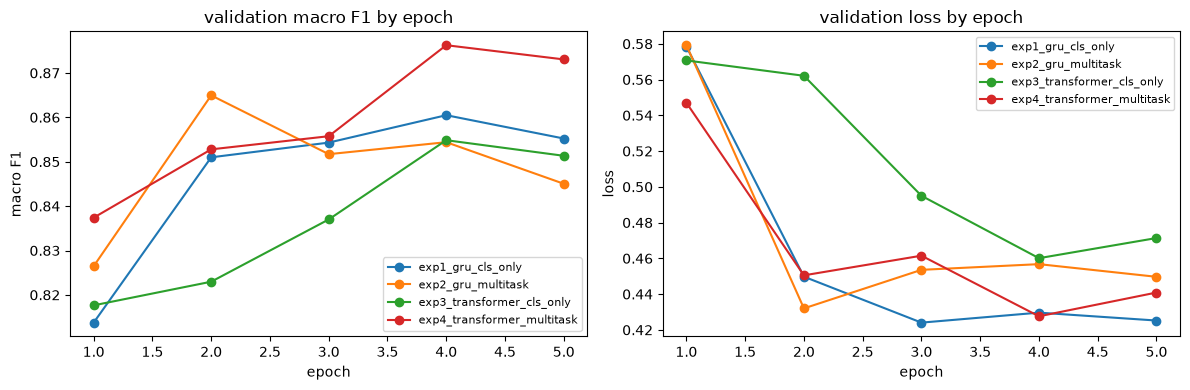

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, r in all_results.items():
    epochs = [h["epoch"] for h in r["history"]]
    val_f1 = [h["val"]["macro_f1"] for h in r["history"]]
    val_loss = [h["val"]["loss"] for h in r["history"]]
    axes[0].plot(epochs, val_f1, marker="o", label=name)
    axes[1].plot(epochs, val_loss, marker="o", label=name)

axes[0].set_title("validation macro F1 by epoch")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("macro F1")
axes[0].legend(fontsize=8)

axes[1].set_title("validation loss by epoch")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Confusion matrices (test set, best checkpoint per experiment)

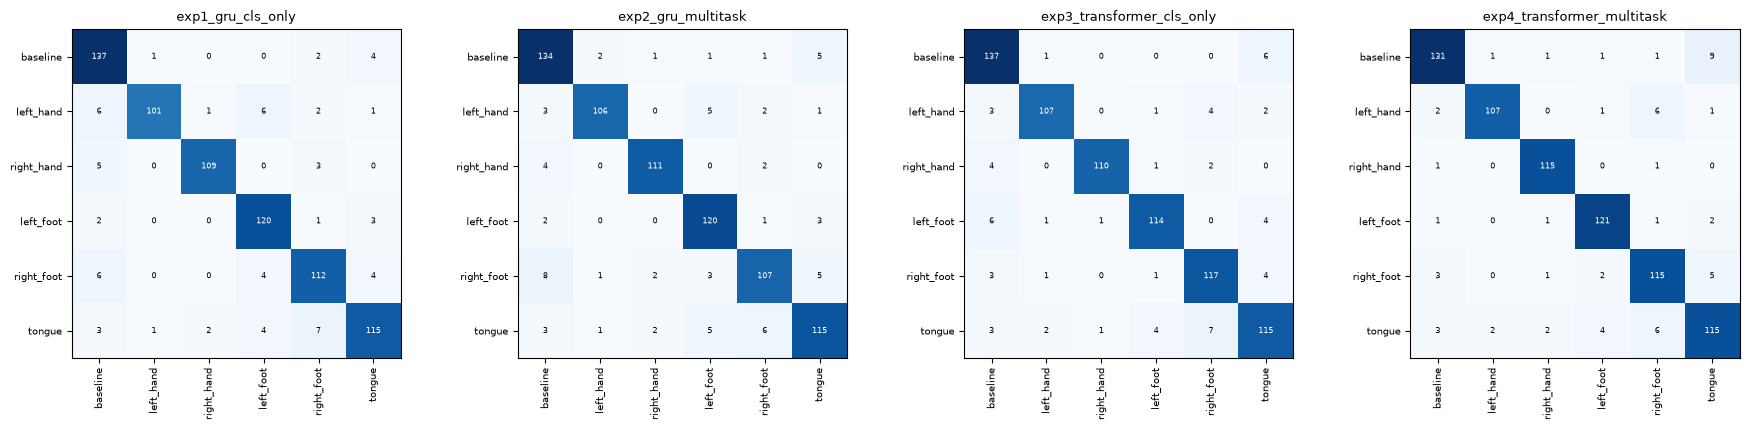

In [5]:
class_names = [info["class_to_condition"][str(c)] for c in range(info["num_classes"])]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (name, r) in zip(axes, all_results.items()):
    cm = np.array(r["test_metrics"]["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=9)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, fontsize=7)
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names, fontsize=7)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.tight_layout()
plt.show()


## HRF regression quality (multi-task experiments only)

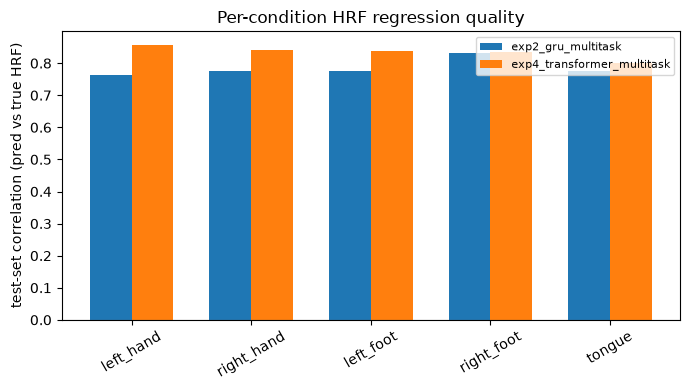

In [6]:
hrf_experiments = {name: r for name, r in all_results.items() if r["test_metrics"]["hrf_mse"] is not None}
condition_names = info["condition_names"]

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
x_pos = np.arange(len(condition_names))
for i, (name, r) in enumerate(hrf_experiments.items()):
    corr = r["test_metrics"]["hrf_per_condition_correlation"]
    ax.bar(x_pos + i * width, corr, width=width, label=name)
ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(condition_names, rotation=30)
ax.set_ylabel("test-set correlation (pred vs true HRF)")
ax.set_title("Per-condition HRF regression quality")
ax.legend(fontsize=8)
ax.axhline(0, color="gray", linewidth=0.8)
fig.tight_layout()
plt.show()


## Save consolidated results

In [7]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    return obj


summary = {
    "config": {
        "num_epochs": NUM_EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "lambda_hrf": LAMBDA_HRF,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "window_length": 32,
        "stride": 2,
        "train_subjects": ["100307", "100408", "101006"],
        "val_subjects": ["101107"],
        "test_subjects": ["101309"],
    },
    "comparison_table": comparison_df.to_dict(orient="records"),
    "experiments": {
        name: {
            "encoder": r["encoder"],
            "objective": r["objective"],
            "n_params": r["n_params"],
            "best_val_macro_f1": r["best_val_macro_f1"],
            "test_metrics": r["test_metrics"],
            "history": r["history"],
        }
        for name, r in all_results.items()
    },
}

results_path = RESULTS_DIR / "motor_v1_results.json"
with open(results_path, "w") as f:
    json.dump(make_json_safe(summary), f, indent=2)

print("saved:", results_path)
comparison_df


saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/motor_v1_results.json


,experiment,encoder,objective,params,best_val_macro_f1,test_macro_f1,test_accuracy,test_balanced_accuracy,test_hrf_mse,test_hrf_mae
0,exp1_gru_cls_only,GRU,classification-only,165894,0.8605,0.9118,0.9108,0.9098,NaN,NaN
1,exp2_gru_multitask,GRU,classification + HRF,166539,0.8650,0.9106,0.9094,0.9097,0.0476,0.1689
2,exp3_transformer_cls_only,Transformer,classification-only,304262,0.8548,0.9200,0.9186,0.9184,NaN,NaN
3,exp4_transformer_multitask,Transformer,classification + HRF,304907,0.8762,0.9252,0.9239,0.9252,0.0363,0.1428


## Summary

All four experiments trained for 5 epochs on the MOTOR-task decoding problem
(3 train / 1 val / 1 test subjects, subject-level split). See the comparison
table above for exact numbers, and `results/motor_v1_results.json` for the
full per-epoch history. Findings are written up in
[docs/ml-design-report.md §9](../docs/ml-design-report.md#9-results).
